# 12 — Calculate vega

Measure how option values respond to a one percentage-point increase in implied volatility.

Vega exists only for optional products. Implied volatility is the market pricing input for expected variability, not the underlying price itself.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

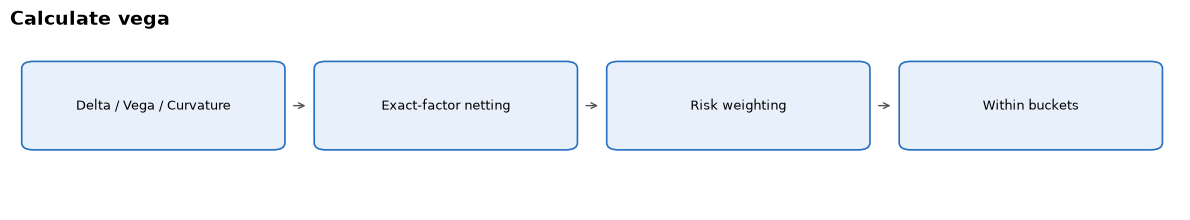

In [2]:
draw_flow(['Delta / Vega / Curvature', 'Exact-factor netting', 'Risk weighting', 'Within buckets'],'Calculate vega',wrap_after=4)

Increase implied volatility by 0.01, reprice the option and divide the change by 0.01 to obtain price vega. Multiply price vega by the current implied volatility to obtain the Basel vega sensitivity. Option maturity remains part of factor identity.

$$\text{Price vega}_k=\frac{V(\sigma_k+0.01)-V(\sigma_k)}{0.01},\qquad s_k^{vega}=\text{Price vega}_k\times\sigma_k$$

In [3]:
from frtb_engine.parameters import risk_weight
vega=pd.read_csv(RUN/'04_vega_trade_level.csv')
vega['one_vol_point_change_inr']=vega.shocked_value_inr-vega.base_value_inr
vega['applicable_risk_weight']=vega.apply(lambda row:risk_weight(row.to_dict(),'VEGA'),axis=1)
columns=['trade_id','desk','instrument_type','risk_class','risk_factor_id','tenor',
         'applicable_risk_weight','base_value_inr','shocked_value_inr','one_vol_point_change_inr','raw_sensitivity']
shown=crore_table(vega[columns],['base_value_inr','shocked_value_inr','one_vol_point_change_inr','raw_sensitivity'])
display(percent_columns(shown,['applicable_risk_weight']))
print('The vega risk weight is shown for reference and is applied after exact-factor netting in Notebook 18.')
example=vega.iloc[0]
print(f"Worked trade {example.trade_id}: INR {example.one_vol_point_change_inr:,.2f} change for one volatility percentage point")

,trade_id,desk,instrument_type,risk_class,risk_factor_id,tenor,Applicable Risk Weight (%),Base Value (INR crore),Shocked Value (INR crore),One Vol Point Change (INR crore),Raw Sensitivity (INR crore per unit change)
0,R09,Rates,SWAPTION,GIRR,INR_OIS_VOL_1.0Y_UNDERLYING_5.0Y,1.0000,100.0000,0.4181,0.4297,0.0115,0.2078
1,R09,Rates,SWAPTION,GIRR,INR_OIS_VOL_3.0Y_UNDERLYING_5.0Y,3.0000,100.0000,0.4181,0.4297,0.0115,0.2078
2,R10,Rates,SWAPTION,GIRR,USD_OIS_VOL_1.0Y_UNDERLYING_10.0Y,1.0000,100.0000,1.0027,1.0228,0.0200,0.4005
3,R10,Rates,SWAPTION,GIRR,USD_OIS_VOL_3.0Y_UNDERLYING_10.0Y,3.0000,100.0000,1.0027,1.0228,0.0200,0.4005
4,C07,Credit,CREDIT_OPTION,CSR_NON_SECURITISATION,US_INDUSTRIAL_VOL_1.0Y,1.0000,100.0000,0.0830,0.0852,0.0022,0.0779
5,C08,Credit,CALLABLE_BOND,CSR_NON_SECURITISATION,EU_UTILITY_VOL_1.0Y,1.0000,100.0000,8.1260,8.1007,-0.0253,-0.5560
6,C08,Credit,CALLABLE_BOND,CSR_NON_SECURITISATION,EU_UTILITY_VOL_3.0Y,3.0000,100.0000,8.1260,8.1007,-0.0253,-0.5560
7,E03,Equity,EQUITY_OPTION,EQUITY,RELIANCE_VOL_0.5Y,0.5000,77.7800,1.3522,1.3932,0.0410,1.1478
8,E09,Equity,EQUITY_OPTION,EQUITY,NIFTY50_VOL_0.5Y,0.5000,77.7800,-1.9304,-1.9958,-0.0654,-1.3088
9,E10,Equity,BARRIER_OPTION,EQUITY,NIFTY50_VOL_1.0Y,1.0000,77.7800,0.4535,0.4060,-0.0474,-0.9485


The vega risk weight is shown for reference and is applied after exact-factor netting in Notebook 18.
Worked trade R09: INR 115,469.90 change for one volatility percentage point


The visual below uses the calculated rows shown above.

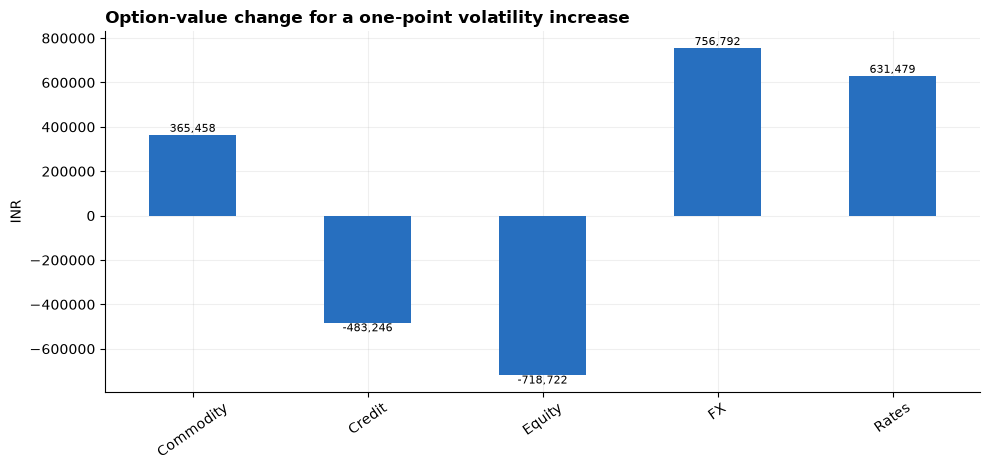

In [4]:
bar_inr(vega.groupby('desk')['one_vol_point_change_inr'].sum(),'Option-value change for a one-point volatility increase')

Vega remains separate from delta because it measures a different market driver.